# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [2]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

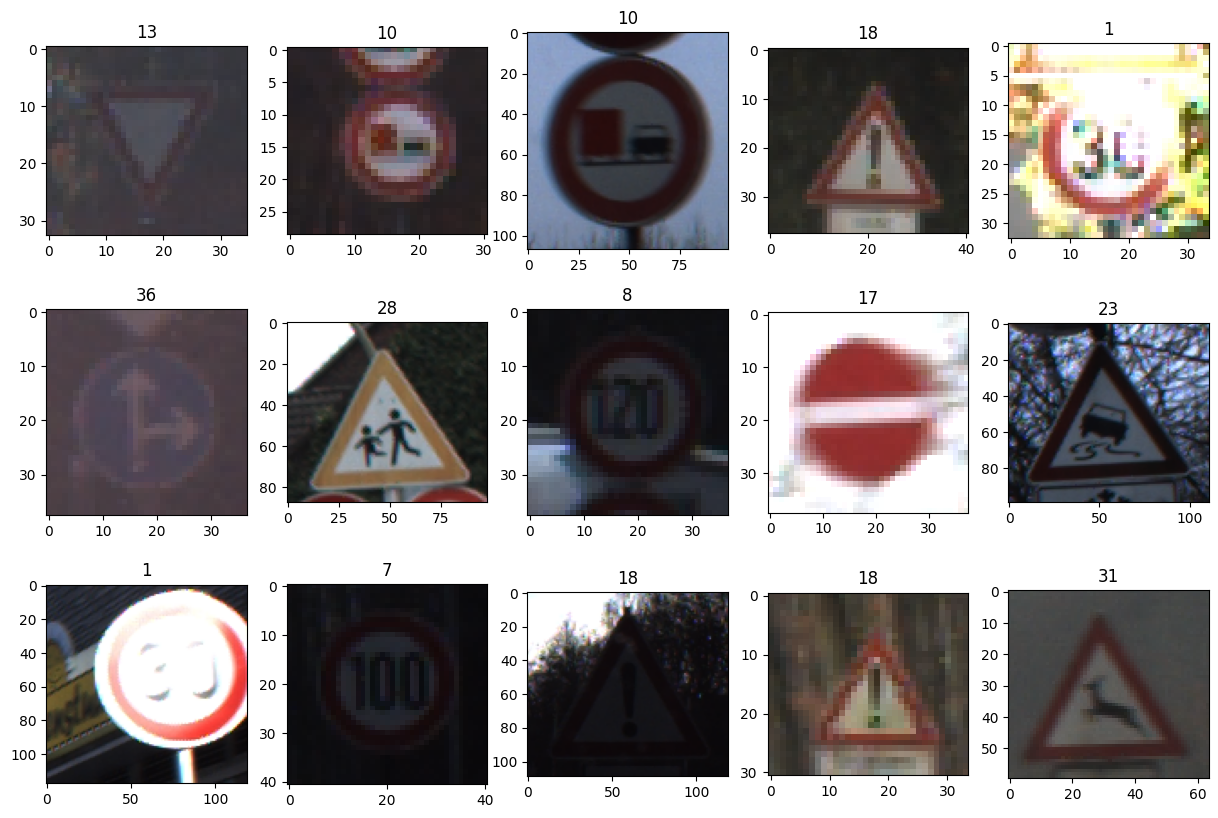

In [3]:
# Load the training labels
root = 'data/GTSRB' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [4]:
# Extract class identifiers
# Hint: Check the csv 
ids = data['ClassId'].values

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

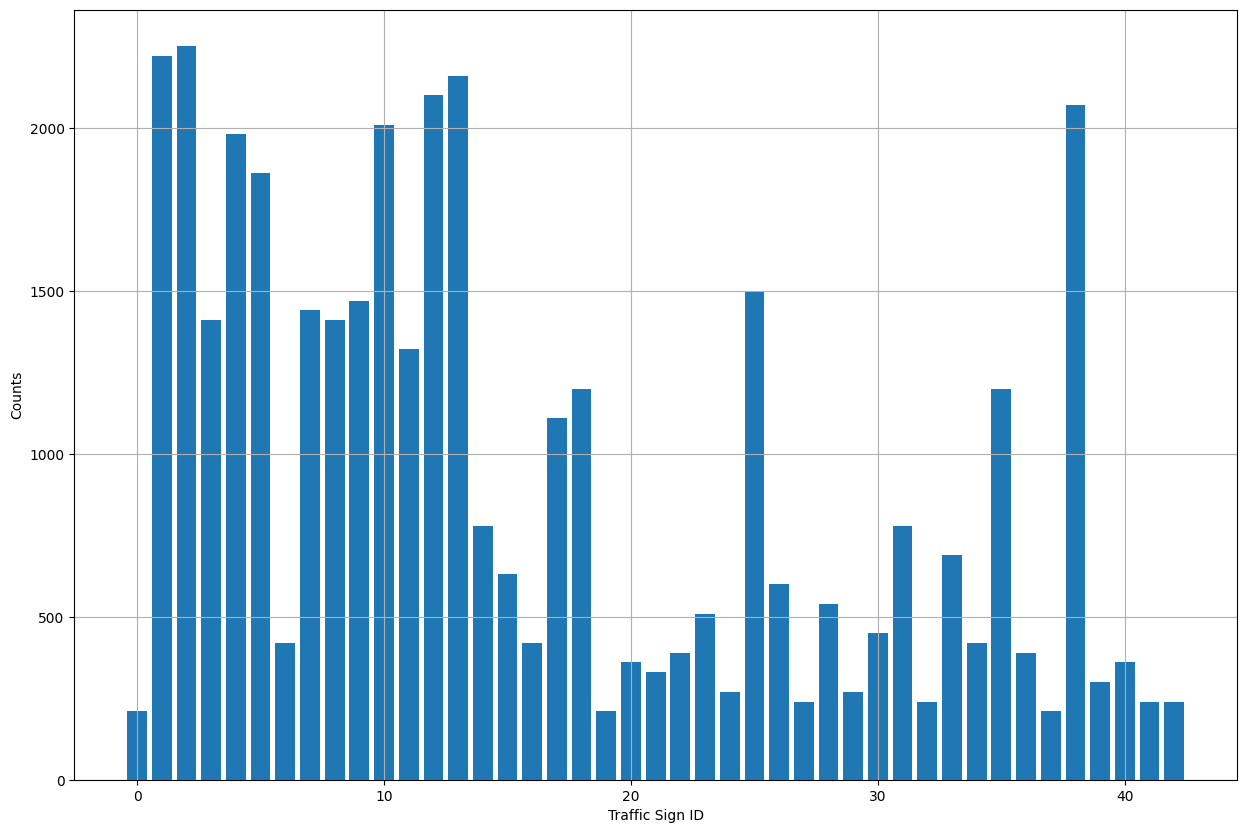

In [5]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

Class 1 has 2220 images
Class 2 has 2250 images
Class 10 has 2010 images
Class 12 has 2100 images
Class 13 has 2160 images
Class 38 has 2070 images
Class 0 has 210 images
Class 19 has 210 images
Class 27 has 240 images
Class 32 has 240 images
Class 37 has 210 images
Class 41 has 240 images
Class 42 has 240 images


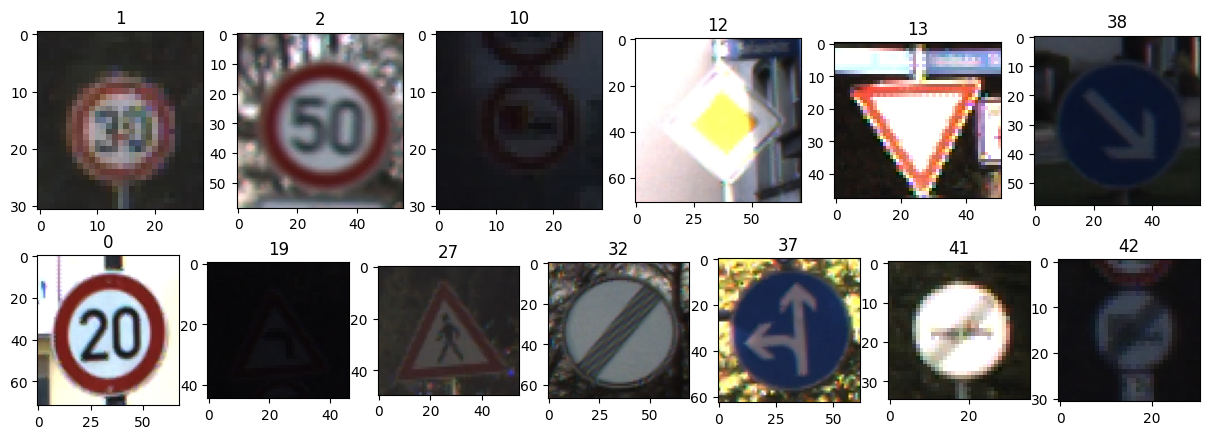

In [6]:
def plot_classes(data, classes, row):
    num_classes = len(classes)
    num_class = 1
    for class_id in classes.index:
        samples = data[data['ClassId'] == class_id]
        num_samples = len(samples)
        print(f"Class {class_id} has {len(samples)} images")

        idx = np.random.randint(0, num_samples)
        
        img_path = os.path.join(root, samples.iloc[idx]['Path'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(row, num_classes, num_class), plt.imshow(img), plt.title(samples.iloc[idx]['ClassId'])
        num_class += 1

grouped = data.groupby('ClassId')
class_counts = grouped.size()

over_represented = class_counts[class_counts > 2000]
under_represented = class_counts[class_counts < 250]

plot_classes(data, over_represented, 2)
plot_classes(data, under_represented, 1)


1. Нет GTSRB dataset не сбалансирован. Сбалансированный набор данных должен иметь приблизительно равное количество реализаций для каждого класса. В GTSRB dataset количество изображений по классам отличается значительно. Некоторые классы имееют более 2000 изображений, а некоторые около 200 изображений.

2. Среди перепредставленных классов или классов с изображениями в избытке (больше 2000 изображений) можно выделять ограничения скорости 30 и 50 км/ч, обгон запрещен, главная дорога, уступить доррогу и объезд препятсвия с правой стороны. Среди недопредставленных классов (менее 250 изображений) можно выделить ограничение скорости 20 км/ч, резкий поворот, предупреждение о пешеходном переходе, конец всех ограничений, предписывающий знак движения прямо и налево, конец ограничения на обгон, конец ограничения на обгон грузовым транспортным средствам. 

Такой дисбаланс изображений классов может привести к смещению обучения модели в сторону чрезмерно представленных классов. Поэтому необходима либо взвешения классов или дополнения данных. 

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?

Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

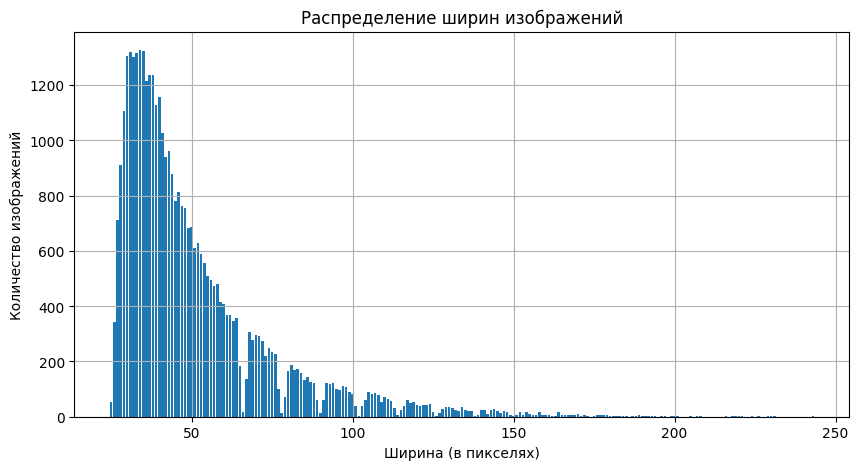

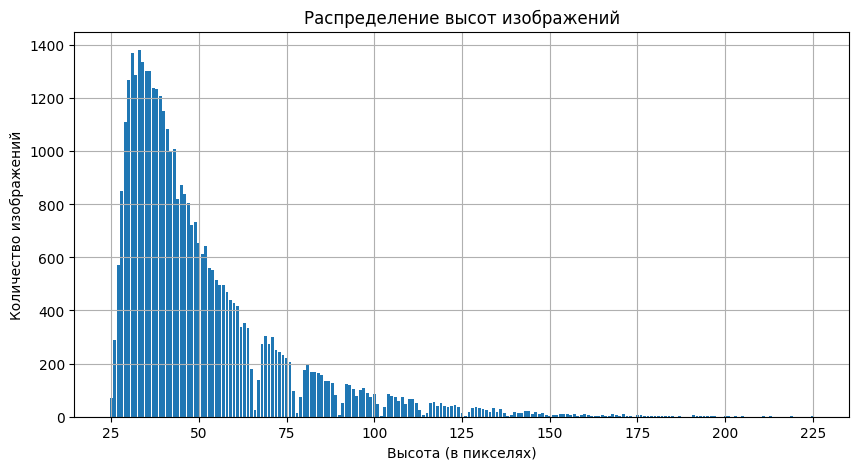

In [7]:
width_counts = data['Width'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(width_counts.index, width_counts.values)
plt.title('Распределение ширин изображений')
plt.xlabel('Ширина (в пикселях)')
plt.ylabel('Количество изображений')
plt.grid(True)
plt.show()

height_counts = data['Height'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(height_counts.index, height_counts.values)
plt.title('Распределение высот изображений')
plt.xlabel('Высота (в пикселях)')
plt.ylabel('Количество изображений')
plt.grid(True)
plt.show()



#samples = data[data['ClassId'] == class_id]

1. По графикам видно, что изображения имеют разные соотношения высот и ширин. Необходимо дополнительно обрабатывать данные изображения, чтобы привести их к одному разрешению.  

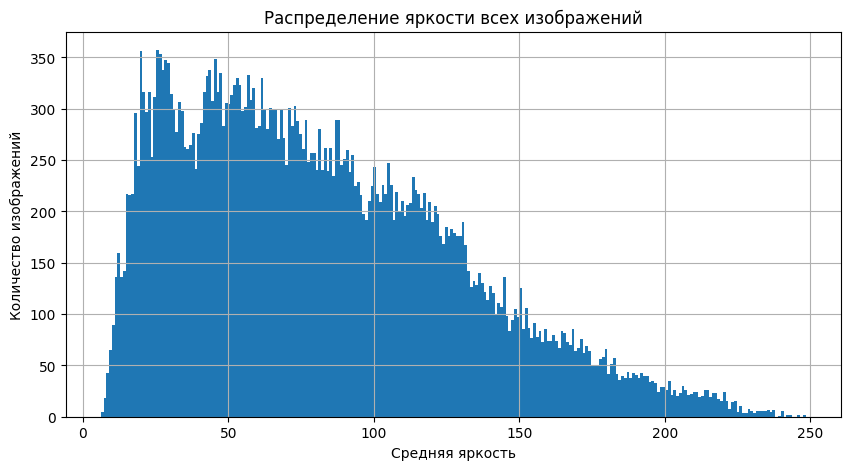

In [8]:
brightness = []

for path in data['Path']:
    img = cv2.imread(os.path.join(root, path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(np.mean(gray))

data['Brightness'] = brightness

plt.figure(figsize=(10, 5))
plt.hist(data['Brightness'].dropna(), bins=256)
plt.title('Распределение яркости всех изображений')
plt.xlabel('Средняя яркость')
plt.ylabel('Количество изображений')
plt.grid(True)
plt.show()

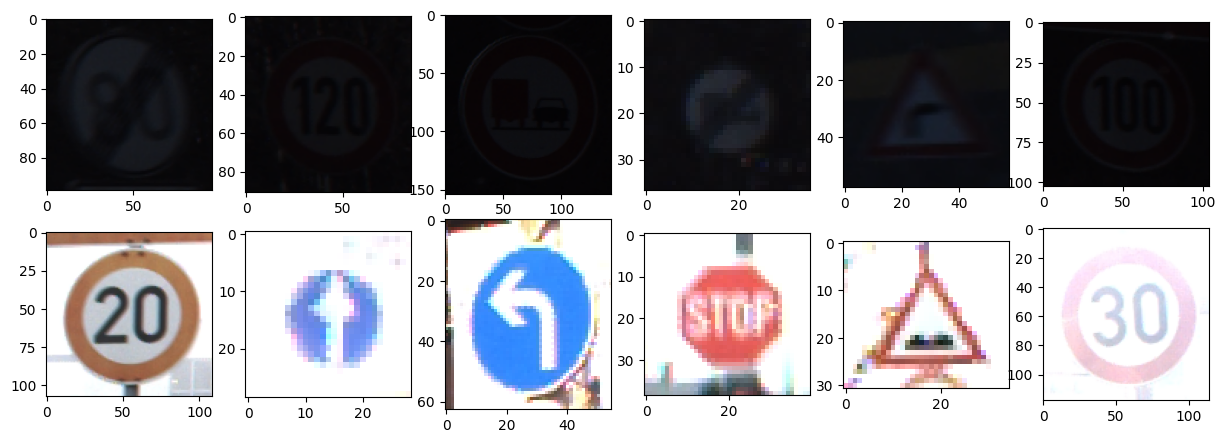

In [68]:

class_brightness = data.groupby('ClassId')['Brightness'].mean().sort_values(ascending=False)
num_classes = len(class_brightness) - 1

for index in range(6):
    samples = data[data['ClassId'] == class_brightness.index[index]] # информация о классах с самыми высокими значениями яркости
    sample = samples[samples['Brightness'] == samples['Brightness'].max()] # выбор изображения с максимальным значением яркости в классе
  
    img = cv2.imread(os.path.join(root, sample['Path'].values[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 6, index + 1), plt.imshow(img)


    samples = data[data['ClassId'] == class_brightness.index[num_classes - index]] # информация о классах с самыми низкими значениями яркости
    sample = samples[samples['Brightness'] == samples['Brightness'].min()] # выбор изображения с минимальным значением яркости в классе

    img = cv2.imread(os.path.join(root, sample['Path'].values[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 6, index + 1), plt.imshow(img)







На рисунки показаны по одному самому яркому и самому темному изображению из пяти самых темных и пяти самых якрих классов.
Самый темный класс может содеражть изображения сделаные с плохим освещением или темным фоном. Самые яркие изображения могут иметь светлый фон или сделаны при ярком дневном свете. Значительные отличия по яркости изображений может повлиять на качество обучения модели, делая ее чувствительной к условиям освещения. Для нормализации и выравнивания яркости можно попробывать использовать эквализацию гистограмм, локальное выравнивание CLAHE, гамма коррекцию. 